In [1]:
import py_ttcross as ttc
from py_ttcross.quantic_tt_cross.interpolators_1D import (
    greedy_one_dim_func_interpolator,
    ttrc_one_dim_func_interpolator,
)
import numpy as np
import matplotlib.pyplot as plt
from py_ttcross.pdes.operators import OneDimLaplacian
from py_ttcross.pdes.als import *

In [2]:
def target_func(x):
    return 2 * 0.3 + 6 * 0.1 * x - 12 * 0.6 * x ** 2 + 20 * 0.2 * x ** 3

def sol_func(x):
    return (0.3 * (x ** 2)) + (0.1 * (x ** 3)) - (0.6 * x ** 4) + (0.2 * x ** 5)

# def func(x):
#     return np.sin(3 * x)

# def exact_func(x):
#     return -np.sin(3 * x)/((3 )**2)


In [3]:
import numba as nb

@nb.njit()
def target_func(x):
    return 2 * 0.3 + 6 * 0.1 * x - 12 * 0.6 * x ** 2 + 20 * 0.2 * x ** 3


# 1. Encoding the target function in TT-Cross format

In [4]:
# interval = [-np.pi, np.pi]
interval = [0, 1]
d = 5

target_interpolator = greedy_one_dim_func_interpolator(
    func=target_func,
    interval=interval,
    d=d,
    complex_function=False,
    max_bond=10,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

target_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.14330506324768066 seconds and 1 tries.
Sweep 1
Sweep 2
Sweep 3


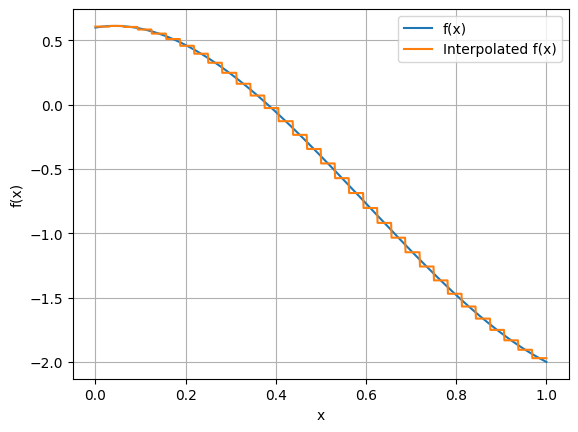

In [5]:
# We can check how the TT-Cross based algorithms obtain a good interpolation of the function

x = np.linspace(interval[0], interval[1], 1000)

true_target = [target_func(x_i) for x_i in x]

interpolation_target = np.array([target_interpolator.eval(x_i) for x_i in x])

plt.plot(x, true_target, label="f(x)")
plt.plot(x, interpolation_target, label="Interpolated f(x)")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Optimizing according the PDE, starting from a random tensor train

In [6]:
laplacian = OneDimLaplacian(d, interval[1]- interval[0])

optimization_als = TTGMRES(target_interpolator.mps, laplacian.laplacian,  4, 8, 1e-18, 3)

optimization_als.optimize()

(array([array([[-0.31521205, -0.94902126],
               [-0.94902126,  0.31521205]]),
        array([[[-1.99124946e-01,  1.98871627e-02, -3.40656938e-04,
                 -5.80618158e-05],
                [-1.71115051e-01, -3.80626493e-02, -3.14144734e-04,
                  4.96352095e-05]],
 
               [[ 4.50809825e-02,  1.14878367e-02, -2.15237629e-03,
                  1.27114173e-05],
                [-6.21183911e-02,  4.94369686e-02,  3.95324934e-04,
                  5.86181908e-05]]])                               ,
        array([[[-7.14423985e-01, -1.87092390e-02, -5.72939122e-05,
                  2.97918423e-07],
                [-6.98877519e-01,  2.86102042e-02, -1.26390767e-05,
                 -5.77993931e-06]],
 
               [[-6.00672506e-01,  2.57513311e-01,  1.00224213e-03,
                  6.58712419e-05],
                [ 6.24638848e-01,  4.27439548e-01, -4.08779469e-04,
                 -3.98405430e-05]],
 
               [[-9.09677030e-02,  7.30119747

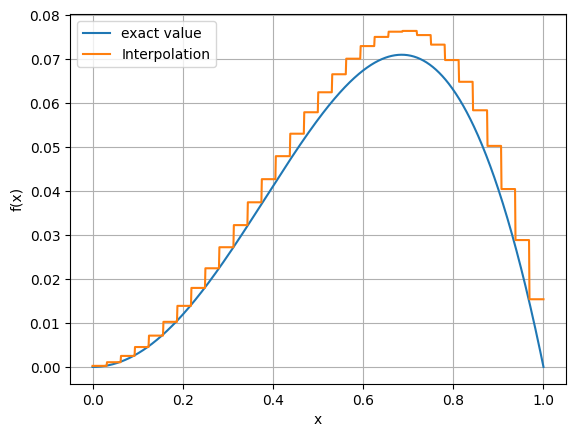

In [7]:
optimized_interpolator = greedy_one_dim_func_interpolator.load_mps(optimization_als.opt_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

y = [sol_func(x_i) for x_i in x]

interpolation = np.array([optimized_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Refining the grid

In [8]:
prolong_als = Prolongation(optimization_als.opt_mps, 10, 12, 1e-10, 5)

prolong_als.optimize()

(array([array([[-0.32514268+0.00000000e+00j,  0.94566497+0.00000000e+00j],
               [-0.94566497+6.79401417e-64j, -0.32514268+2.33594773e-64j]]),
        array([[[-2.83062113e-01-1.76906213e-82j,
                  2.76240289e-02+0.00000000e+00j,
                  5.32898576e-04+6.86738947e-83j,
                 -9.22938691e-05+9.13746382e-84j],
                [-2.36110026e-01+3.24018739e-65j,
                 -5.67371006e-02-2.40697157e-65j,
                  4.16318221e-04+6.49090256e-67j,
                  8.08568866e-05-2.51111634e-68j]],
 
               [[-6.46086363e-02-2.26684621e-65j,
                 -1.77648990e-02+1.36429354e-65j,
                 -2.98255067e-03-1.88005933e-66j,
                 -2.40846302e-05-5.35478559e-69j],
                [ 9.27877246e-02-1.09403143e-64j,
                 -7.24734681e-02+1.82296744e-65j,
                  6.08289207e-04+4.99411153e-67j,
                 -9.25752965e-05+7.56451541e-68j]]]),
        array([[[-7.15807472e-01-4.959

/home/pau/phd/py_ttcross/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/pau/phd/py_ttcross/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


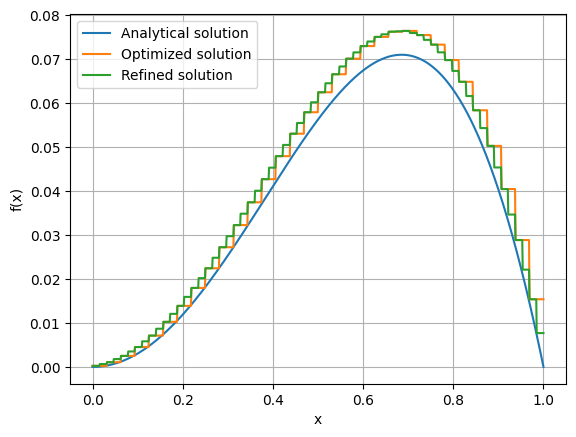

In [9]:
prolongated_interpolator = greedy_one_dim_func_interpolator.load_mps(prolong_als.fine_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

true_solution = [sol_func(x_i) for x_i in x]

optimized_solution = np.array([optimized_interpolator.eval(x_i) for x_i in x])

refined_solution = np.array([prolongated_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="Analytical solution")
plt.plot(x, optimized_solution, label="Optimized solution")
plt.plot(x, refined_solution, label="Refined solution")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 4. Re-optimizing the solution

In [10]:
refined_target_interpolator = greedy_one_dim_func_interpolator(
    func=target_func,
    interval=interval,
    d=d + 1,
    complex_function=False,
    max_bond=10,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

refined_target_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.0070648193359375 seconds and 1 tries.
Sweep 1
Sweep 2
Sweep 3


In [11]:
refined_laplacian = OneDimLaplacian(d + 1, interval[1]- interval[0])

reoptimization_als = TTGMRES(refined_target_interpolator.mps, refined_laplacian.laplacian,  4, 8, 1e-18, 3, prolong_als.fine_mps)

reoptimization_als.optimize()

(array([array([[-0.30856252+0.00000000e+00j,  0.95120406+0.00000000e+00j],
               [-0.95120406-7.59981765e-81j, -0.30856252-2.46531635e-81j]]),
        array([[[-2.71751919e-01-2.35477386e-099j,
                  2.73778518e-02-1.92700315e-098j,
                  5.20334346e-04+5.71538180e-099j,
                 -9.33127942e-05-1.93089130e-100j],
                [-2.26234022e-01-6.75256218e-082j,
                 -5.56977122e-02-1.84859339e-082j,
                  4.45446809e-04-9.09916313e-084j,
                  8.02852392e-05+9.11920364e-086j]],
 
               [[-6.06119764e-02-1.53234473e-082j,
                 -1.57073380e-02-3.25856901e-083j,
                 -3.17422439e-03+3.12881526e-083j,
                 -2.12021307e-05+4.54383190e-085j],
                [ 8.80013294e-02+5.12814673e-082j,
                 -6.94624334e-02-4.47729348e-082j,
                  5.65685391e-04+3.56356136e-084j,
                 -9.63596961e-05-5.93253213e-085j]]]),
        array([[[-7.16

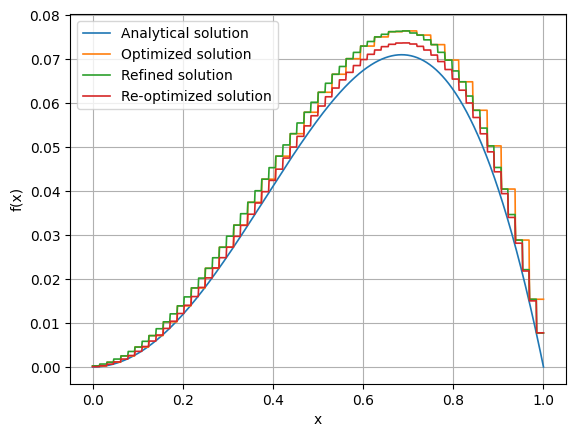

In [12]:
reoptimized_interpolator = greedy_one_dim_func_interpolator.load_mps(reoptimization_als.opt_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

true_solution = [sol_func(x_i) for x_i in x]

optimized_solution = np.array([optimized_interpolator.eval(x_i) for x_i in x])
refined_solution = np.array([prolongated_interpolator.eval(x_i) for x_i in x])
reoptimized_solution = np.array([reoptimized_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="Analytical solution", linewidth=1.2)
plt.plot(x, optimized_solution, label="Optimized solution", linewidth=1.2)
plt.plot(x, refined_solution, label="Refined solution", linewidth=1.2)
plt.plot(x, reoptimized_solution, label="Re-optimized solution", linewidth=1.2)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.savefig("comparison.jpg", dpi=300)
plt.show()